In [144]:
from pathlib import Path
from sklearn.metrics import silhouette_score
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import math

In [145]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_PATH = DATA_DIR / "images.jpeg"

assert IMAGE_PATH.exists(), (
    f"Image not found at {IMAGE_PATH.resolve()}. "
    "Put an image in the data/ folder or update IMAGE_PATH."
)


In [146]:
random_state = 42

Size: (161, 161), Format: None, Mode: RGB


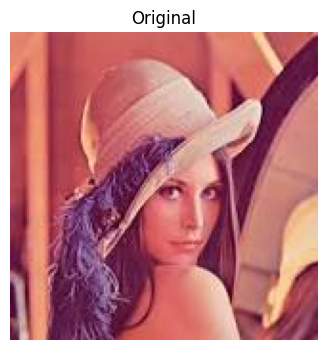

In [147]:
img = Image.open(IMAGE_PATH).convert("RGB")

print(f"Size: {img.size}, Format: {img.format}, Mode: {img.mode}")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Original")
plt.show()


As K-means uses distance, we need to normalize the data.

In [148]:
def compress_image(img_input, n_colors_input):
  image_array_local = np.array(img_input)
  h, w, c = image_array_local.shape
  pixels = image_array_local.reshape(-1, c).astype(np.float64) / 255.0

  kmeans = KMeans(n_clusters=n_colors_input, random_state=random_state, n_init=10)
  kmeans.fit(pixels)
  labels = kmeans.labels_

  palette = kmeans.cluster_centers_
  # Scale back to 0-255 before converting to uint8 for proper image display
  compressed = (palette[labels] * 255).reshape(h, w, c).astype(np.uint8)

  return compressed, kmeans


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

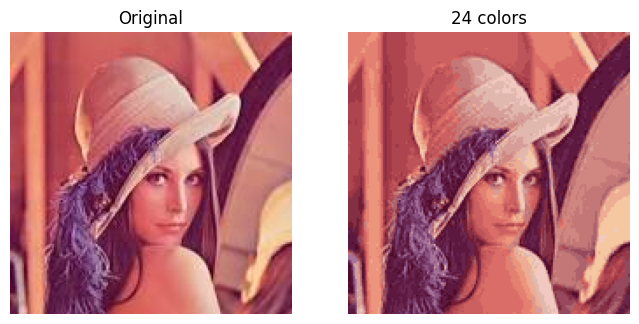

In [149]:
image_array = np.array(img)

compressed_24, kmeans_24 = compress_image(img, n_colors_input=24)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(compressed_24)
axes[1].set_title("24 colors")
axes[1].axis("off")
plt.show()

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

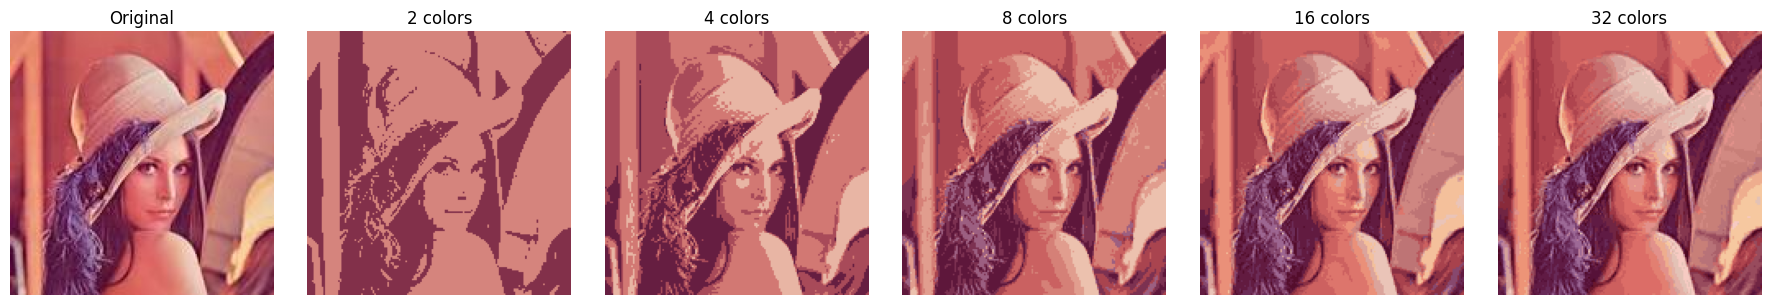

In [150]:
k_values = [2, 4, 8, 16, 32]
results = {}

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(3 * (len(k_values) + 1), 3))

axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, k in zip(axes[1:], k_values):
    compressed_k, model = compress_image(img, n_colors_input=k)
    output_image = Image.fromarray(compressed_k)
    output_path = OUTPUT_DIR / f"compressed_{k}_colors.png"
    output_image.save(output_path)
    results[k] = {"image": compressed_k, "model": model}
    ax.imshow(compressed_k)
    ax.set_title(f"{k} colors")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Inertia** measures how close the data points are to the center of their assigned cluster.

**Silhouette score** shows how pixels closer to their own cluster than to other clusters?

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:2

k= 2  silhouette=0.527
k= 4  silhouette=0.469
k= 8  silhouette=0.378
k=16  silhouette=0.338
k=32  silhouette=0.319


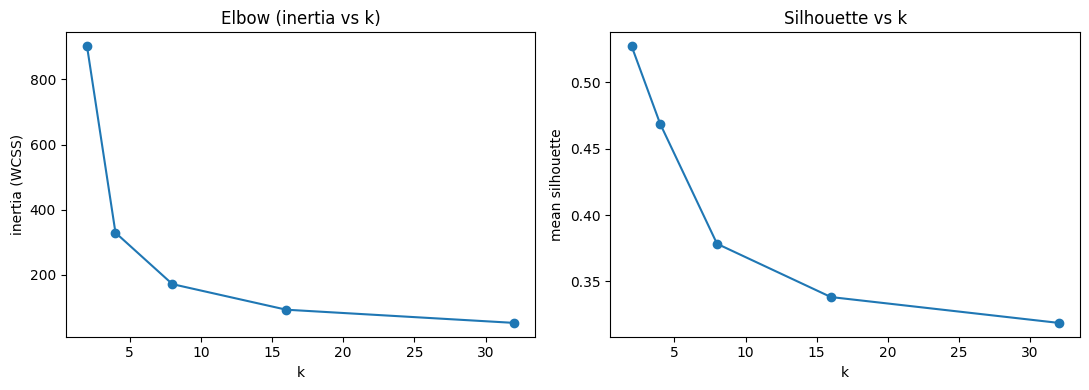

In [151]:
image_array_flat = np.array(img).reshape(-1, 3).astype(np.float64) / 255.0

inertias = [results[k]["model"].inertia_ for k in k_values]
sil_scores = [
    silhouette_score(image_array_flat, results[k]["model"].labels_, sample_size=min(len(image_array_flat), 3000), random_state=random_state)
    for k in k_values
]

for k, sil in zip(k_values, sil_scores):
    print(f"k={k:>2}  silhouette={sil:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_values, inertias, marker="o")
ax[0].set(title="Elbow (inertia vs k)", xlabel="k", ylabel="inertia (WCSS)")
ax[1].plot(k_values, sil_scores, marker="o")
ax[1].set(title="Silhouette vs k", xlabel="k", ylabel="mean silhouette")
plt.tight_layout()
plt.show()

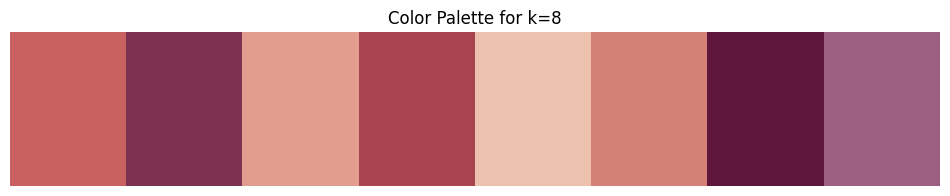

In [152]:
chosen_k = 8

if chosen_k in results:
    palette = results[chosen_k]['model'].cluster_centers_
else:
    kmeans_chosen = KMeans(n_clusters=chosen_k, random_state=random_state, n_init=10)
    kmeans_chosen.fit(image_array_flat)
    palette = kmeans_chosen.cluster_centers_

colors_display = (palette * 255).astype(np.uint8)

plt.figure(figsize=(chosen_k * 1.5, 2))
plt.imshow([colors_display], aspect='auto')
plt.title(f'Color Palette for k={chosen_k}')
plt.axis('off')
plt.show()

8 bits per channel * 3 channels (RGB)

Palette storage: k * 3 bytes (for R, G, B components)

Index storage: ceil(log2 k) bits per pixel

In [153]:
h, w, c = np.array(img).shape
original_bits_per_pixel = 8 * 3
original_total_bits = h * w * original_bits_per_pixel

palette_bytes = chosen_k * 3
palette_bits = palette_bytes * 8

index_bits_per_pixel = math.ceil(math.log2(chosen_k))
index_total_bits = h * w * index_bits_per_pixel

compressed_total_bits = palette_bits + index_total_bits

compression_ratio_per_pixel = original_bits_per_pixel / index_bits_per_pixel
overall_compression_ratio = original_total_bits / compressed_total_bits

print(f"Original image: {h}x{w} pixels, {original_bits_per_pixel} bits/pixel")
print(f"Total original bits: {original_total_bits:,}")
print(f"\nCompressed image with k={chosen_k}:")
print(f"  Palette storage: {palette_bytes} bytes ({palette_bits} bits)")
print(f"  Index storage: {index_bits_per_pixel} bits/pixel")
print(f"  Total index bits: {index_total_bits:,}")
print(f"Total compressed bits (palette + indices): {compressed_total_bits:,}")
print(f"\nCompression Ratio (bits/pixel): {compression_ratio_per_pixel:.2f}x (original {original_bits_per_pixel} / index {index_bits_per_pixel})")
print(f"Overall Compression Ratio (total bits): {overall_compression_ratio:.2f}x")

Original image: 161x161 pixels, 24 bits/pixel
Total original bits: 622,104

Compressed image with k=8:
  Palette storage: 24 bytes (192 bits)
  Index storage: 3 bits/pixel
  Total index bits: 77,763
Total compressed bits (palette + indices): 77,955

Compression Ratio (bits/pixel): 8.00x (original 24 / index 3)
Overall Compression Ratio (total bits): 7.98x


In [154]:
original_image_array = np.array(img)
original_pixels_scaled = original_image_array.astype(np.float64) / 255.0

mse_scores = {}
for k in k_values:
    compressed_image_array = results[k]['image']
    compressed_pixels_scaled = compressed_image_array.astype(np.float64) / 255.0

    mse = mean_squared_error(original_pixels_scaled.reshape(-1, 3), compressed_pixels_scaled.reshape(-1, 3))
    mse_scores[k] = mse
    print(f"k={k:>2}  MSE={mse:.6f}")


k= 2  MSE=0.011609
k= 4  MSE=0.004239
k= 8  MSE=0.002210
k=16  MSE=0.001201
k=32  MSE=0.000679
